In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
sample_submission = pd.read_csv("../input/house-prices-advanced-regression-techniques/sample_submission.csv")
test = pd.read_csv("../input/house-prices-advanced-regression-techniques/test.csv")
train = pd.read_csv("../input/house-prices-advanced-regression-techniques/train.csv")
sample = pd.read_csv("../input/house-prices-advanced-regression-techniques/sample_submission.csv")

In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [5]:
train.corr()['SalePrice'].sort_values()

KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
MSSubClass      -0.084284
OverallCond     -0.077856
YrSold          -0.028923
LowQualFinSF    -0.025606
Id              -0.021917
MiscVal         -0.021190
BsmtHalfBath    -0.016844
BsmtFinSF2      -0.011378
3SsnPorch        0.044584
MoSold           0.046432
PoolArea         0.092404
ScreenPorch      0.111447
BedroomAbvGr     0.168213
BsmtUnfSF        0.214479
BsmtFullBath     0.227122
LotArea          0.263843
HalfBath         0.284108
OpenPorchSF      0.315856
2ndFlrSF         0.319334
WoodDeckSF       0.324413
LotFrontage      0.351799
BsmtFinSF1       0.386420
Fireplaces       0.466929
MasVnrArea       0.477493
GarageYrBlt      0.486362
YearRemodAdd     0.507101
YearBuilt        0.522897
TotRmsAbvGrd     0.533723
FullBath         0.560664
1stFlrSF         0.605852
TotalBsmtSF      0.613581
GarageArea       0.623431
GarageCars       0.640409
GrLivArea        0.708624
OverallQual      0.790982
SalePrice        1.000000
Name: SalePr

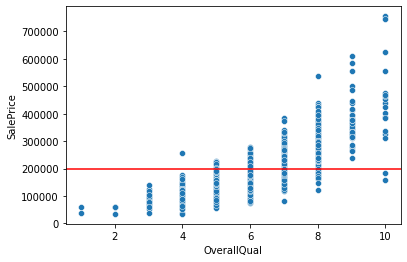

In [6]:
sns.scatterplot(data=train, x='OverallQual', y='SalePrice')
plt.axhline(y=200000,color='r')

In [7]:
train[(train['OverallQual']>8) &(train['SalePrice']<200000)][['SalePrice', 'OverallQual']]

,SalePrice,OverallQual
523,184750,10
1298,160000,10


In [8]:
df = pd.read_csv("../input/house-prices-advanced-regression-techniques/train.csv")

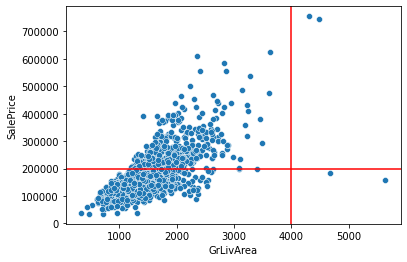

In [9]:
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train)
plt.axhline(y=200000, color='r')
plt.axvline(x=4000, color='r')



<AxesSubplot:xlabel='OverallQual', ylabel='SalePrice'>

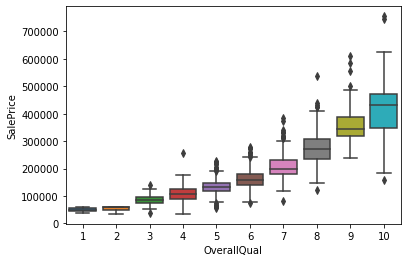

In [10]:


sns.boxplot(x='OverallQual', y='SalePrice', data=train)



In [11]:


#open the documentation about the data set. (this file is in a txt format)

with open('../input/house-prices-advanced-regression-techniques/data_description.txt', 'r') as f:
    print(f.read())



MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

In [12]:


train= train.drop('Id', axis=1)



In [13]:


train.isnull()



,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False
4,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False
1456,False,False,False,False,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False
1457,False,False,False,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1458,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False


In [14]:
train.isnull().sum()

MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
Street             0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 80, dtype: int64

In [15]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [18]:
100*(train.isnull().sum()/len(train))

MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
Street            0.000000
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 80, dtype: float64

In [19]:
def missing_percent(train):
    nan_percent= 100*(train.isnull().sum()/len(train))
    nan_percent= nan_percent[nan_percent>0].sort_values()
    return nan_percent

In [20]:
nan_percent= missing_percent(train)

In [21]:
nan_percent



Electrical       0.068493
MasVnrType       0.547945
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
BsmtExposure     2.602740
BsmtFinType2     2.602740
GarageCond       5.547945
GarageQual       5.547945
GarageFinish     5.547945
GarageType       5.547945
GarageYrBlt      5.547945
LotFrontage     17.739726
FireplaceQu     47.260274
Fence           80.753425
Alley           93.767123
MiscFeature     96.301370
PoolQC          99.520548
dtype: float64

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18]),
 [Text(0, 0, 'Electrical'),
  Text(1, 0, 'MasVnrType'),
  Text(2, 0, 'MasVnrArea'),
  Text(3, 0, 'BsmtQual'),
  Text(4, 0, 'BsmtCond'),
  Text(5, 0, 'BsmtFinType1'),
  Text(6, 0, 'BsmtExposure'),
  Text(7, 0, 'BsmtFinType2'),
  Text(8, 0, 'GarageCond'),
  Text(9, 0, 'GarageQual'),
  Text(10, 0, 'GarageFinish'),
  Text(11, 0, 'GarageType'),
  Text(12, 0, 'GarageYrBlt'),
  Text(13, 0, 'LotFrontage'),
  Text(14, 0, 'FireplaceQu'),
  Text(15, 0, 'Fence'),
  Text(16, 0, 'Alley'),
  Text(17, 0, 'MiscFeature'),
  Text(18, 0, 'PoolQC')])

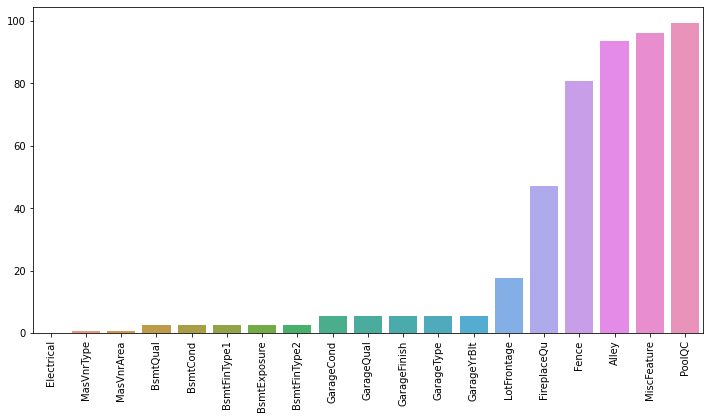

In [22]:
plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)

(0.0, 1.0)

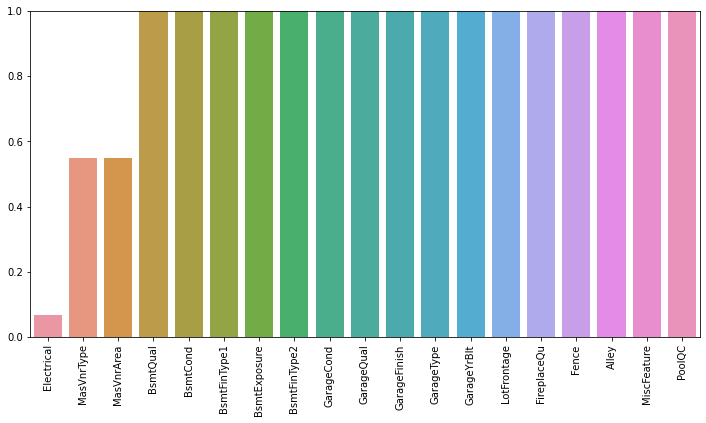

In [23]:

plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)
plt.ylim(0,1)

In [24]:
nan_percent[nan_percent<1]

Electrical    0.068493
MasVnrType    0.547945
MasVnrArea    0.547945
dtype: float64

In [25]:


nan_percent[nan_percent<1].index



Index(['Electrical', 'MasVnrType', 'MasVnrArea'], dtype='object')

In [26]:
100/len(train)

0.0684931506849315

In [27]:
train[train['Electrical'].isnull()]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1379,80,RL,73.0,9735,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,167500


In [28]:
train[train['GarageArea'].isnull()]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


In [29]:
train= train.dropna(axis=0, subset=['Electrical', 'GarageArea','MasVnrArea'])

(0.0, 1.0)

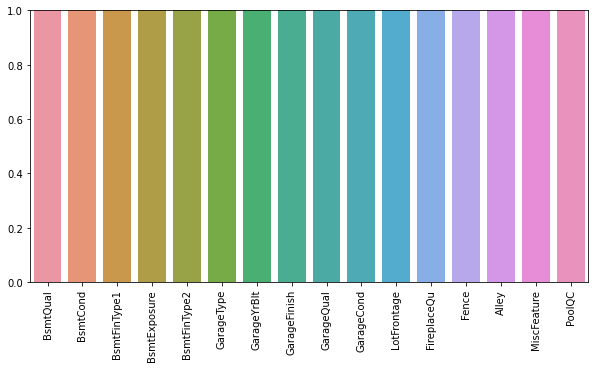

In [30]:
nan_percent= missing_percent(train)

plt.figure(figsize=(10,5))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)
plt.ylim(0,1)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:6: UserWarning: Attempting to set identical bottom == top == 1 results in singular transformations; automatically expanding.
  


(0.95, 1.05)

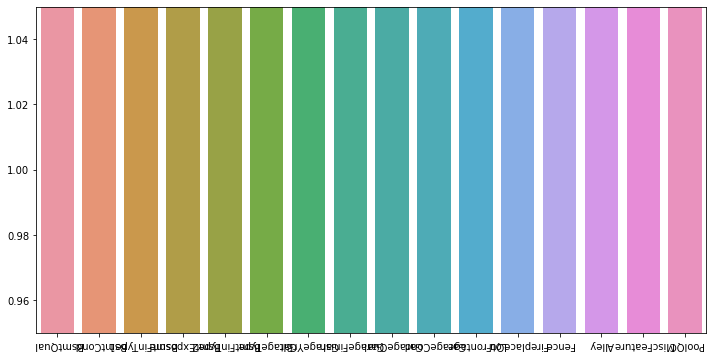

In [31]:
nan_percent= missing_percent(train)

plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=180)
plt.ylim(1,1)

In [32]:


train[train['TotalBsmtSF'].isnull()]



,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


In [33]:
bsmt_num_cols= ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF' ,'BsmtFullBath', 'BsmtHalfBath']
train[bsmt_num_cols]=train[bsmt_num_cols].fillna(0)

#String Columns fill with None:
bsmt_str_cols= ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
train[bsmt_str_cols]= train[bsmt_str_cols].fillna('None')



(0.0, 1.0)

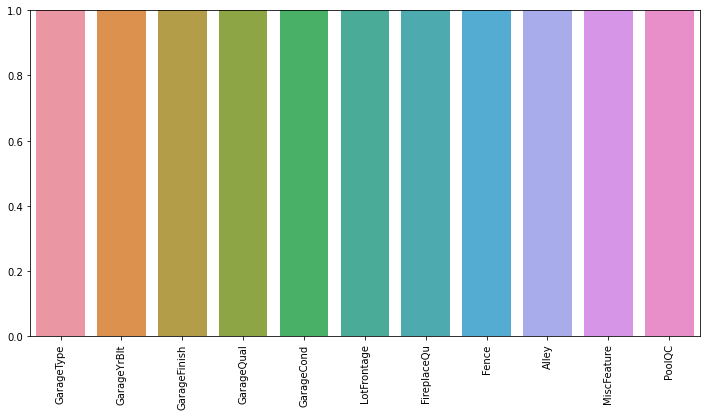

In [34]:


nan_percent= missing_percent(train)

plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)
plt.ylim(0,1)



In [35]:
train["MasVnrType"]= train["MasVnrType"].fillna("None")
train["MasVnrArea"]= train["MasVnrArea"].fillna(0)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 [Text(0, 0, 'GarageType'),
  Text(1, 0, 'GarageYrBlt'),
  Text(2, 0, 'GarageFinish'),
  Text(3, 0, 'GarageQual'),
  Text(4, 0, 'GarageCond'),
  Text(5, 0, 'LotFrontage'),
  Text(6, 0, 'FireplaceQu'),
  Text(7, 0, 'Fence'),
  Text(8, 0, 'Alley'),
  Text(9, 0, 'MiscFeature'),
  Text(10, 0, 'PoolQC')])

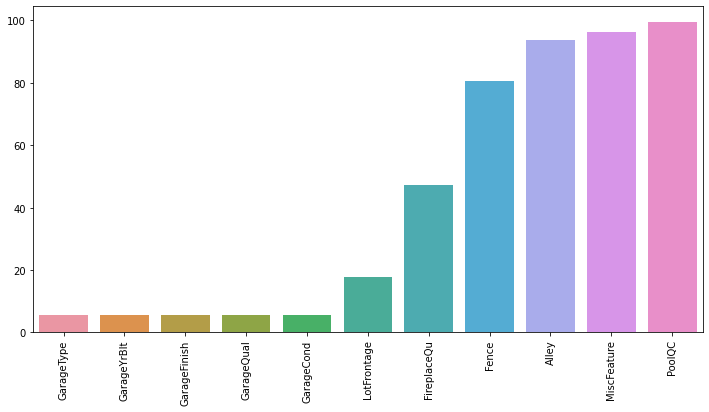

In [36]:
nan_percent= missing_percent(train)

plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)

In [37]:
train[['GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond']]

,GarageType,GarageYrBlt,GarageFinish,GarageQual,GarageCond
0,Attchd,2003.0,RFn,TA,TA
1,Attchd,1976.0,RFn,TA,TA
2,Attchd,2001.0,RFn,TA,TA
3,Detchd,1998.0,Unf,TA,TA
4,Attchd,2000.0,RFn,TA,TA
...,...,...,...,...,...
1455,Attchd,1999.0,RFn,TA,TA
1456,Attchd,1978.0,Unf,TA,TA
1457,Attchd,1941.0,RFn,TA,TA
1458,Attchd,1950.0,Unf,TA,TA


In [38]:
Gar_str_cols= ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
train[Gar_str_cols]=train[Gar_str_cols].fillna('None')

train['GarageYrBlt']=train['GarageYrBlt'].fillna(0)

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'LotFrontage'),
  Text(1, 0, 'FireplaceQu'),
  Text(2, 0, 'Fence'),
  Text(3, 0, 'Alley'),
  Text(4, 0, 'MiscFeature'),
  Text(5, 0, 'PoolQC')])

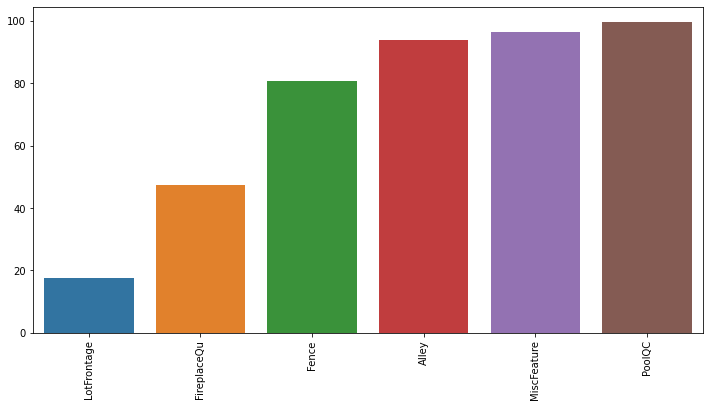

In [39]:
nan_percent= missing_percent(train)

plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)

In [40]:
nan_percent.index

Index(['LotFrontage', 'FireplaceQu', 'Fence', 'Alley', 'MiscFeature',
       'PoolQC'],
      dtype='object')

In [41]:
train[['LotFrontage', 'FireplaceQu', 'Fence', 'Alley', 'MiscFeature',
       'PoolQC']]

,LotFrontage,FireplaceQu,Fence,Alley,MiscFeature,PoolQC
0,65.0,NaN,NaN,NaN,NaN,NaN
1,80.0,TA,NaN,NaN,NaN,NaN
2,68.0,TA,NaN,NaN,NaN,NaN
3,60.0,Gd,NaN,NaN,NaN,NaN
4,84.0,TA,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
1455,62.0,TA,NaN,NaN,NaN,NaN
1456,85.0,TA,MnPrv,NaN,NaN,NaN
1457,66.0,Gd,GdPrv,NaN,Shed,NaN
1458,68.0,NaN,NaN,NaN,NaN,NaN


In [42]:


train= train.drop(['Fence', 'Alley', 'MiscFeature','PoolQC'], axis=1)



(array([0, 1]), [Text(0, 0, 'LotFrontage'), Text(1, 0, 'FireplaceQu')])

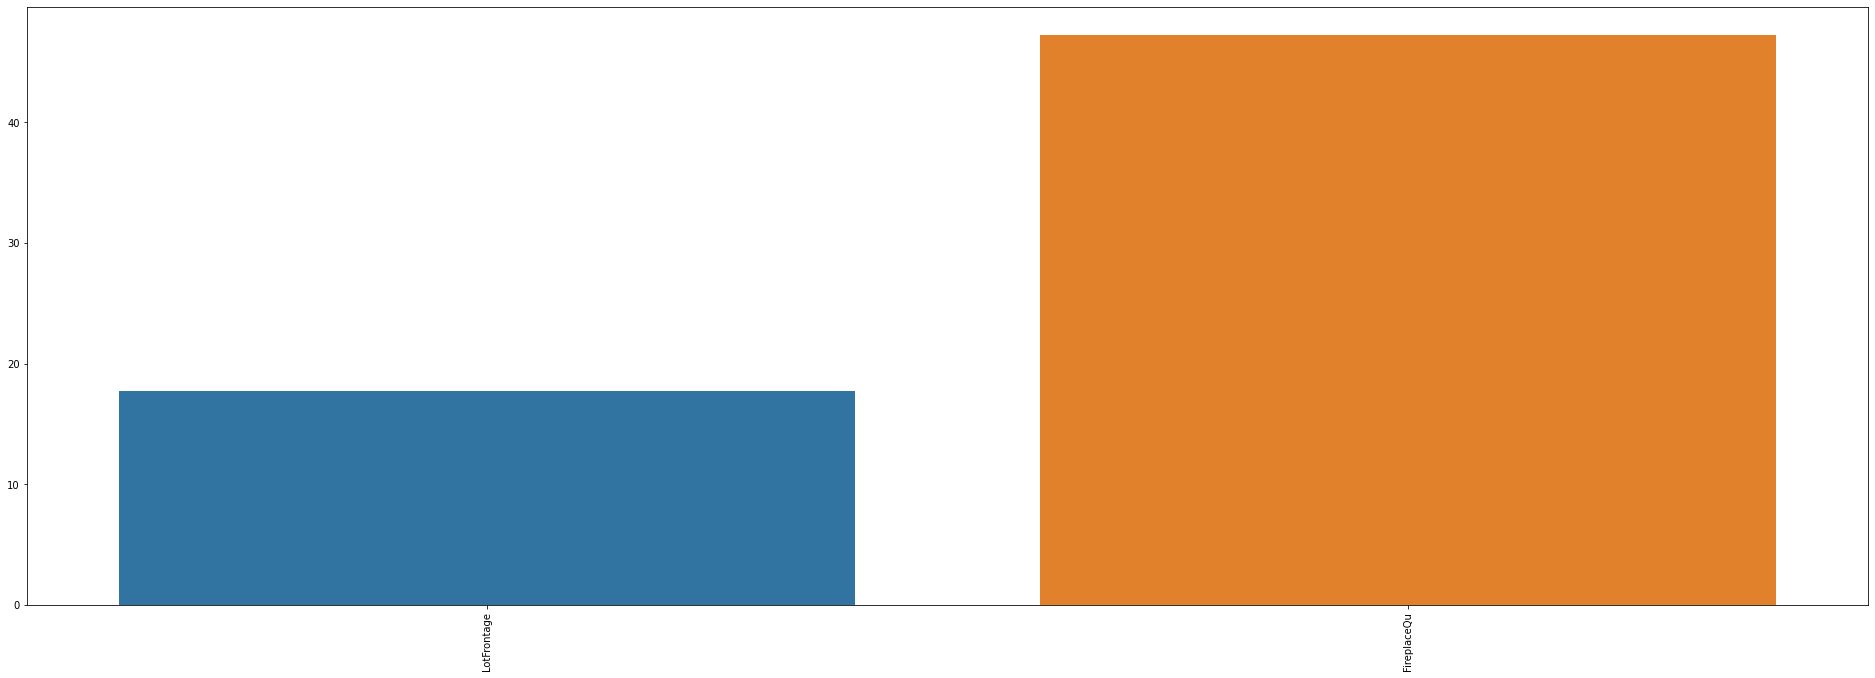

In [43]:


nan_percent= missing_percent(train)

plt.figure(figsize=(33,11))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)



In [44]:
train['FireplaceQu']= train['FireplaceQu'].fillna('None')

(array([0]), [Text(0, 0, 'LotFrontage')])

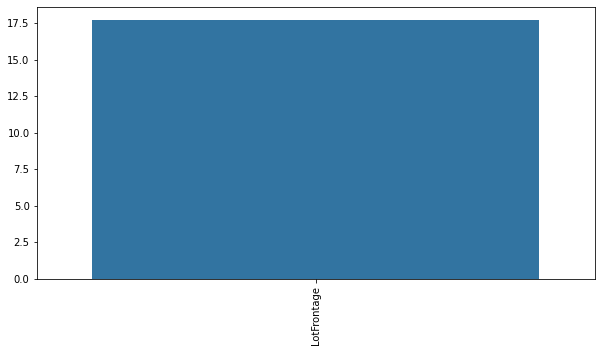

In [45]:
nan_percent= missing_percent(train)

plt.figure(figsize=(10,5))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)

In [46]:


train['Neighborhood'].unique()



array(['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',
       'NWAmes', 'OldTown', 'BrkSide', 'Sawyer', 'NridgHt', 'NAmes',
       'SawyerW', 'IDOTRR', 'MeadowV', 'Edwards', 'Timber', 'Gilbert',
       'StoneBr', 'ClearCr', 'NPkVill', 'Blmngtn', 'BrDale', 'SWISU',
       'Blueste'], dtype=object)

<AxesSubplot:xlabel='LotFrontage', ylabel='Neighborhood'>

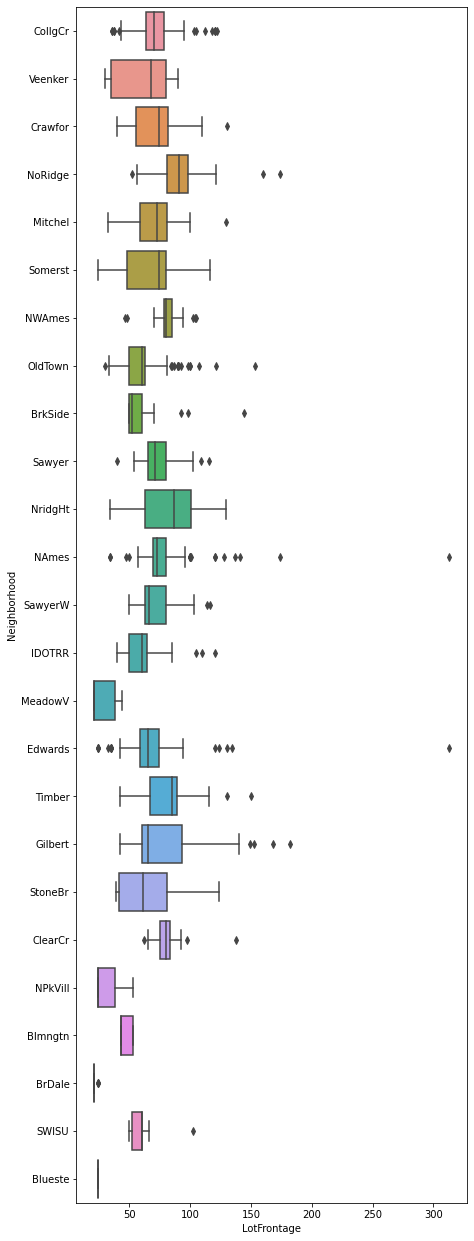

In [47]:
plt.figure(figsize=(7,22))
sns.boxplot(data=train, x='LotFrontage', y='Neighborhood')

In [48]:
train.groupby('Neighborhood')['LotFrontage']

In [49]:
train.groupby('Neighborhood')['LotFrontage'].mean()

Neighborhood
Blmngtn    47.142857
Blueste    24.000000
BrDale     21.562500
BrkSide    57.509804
ClearCr    83.461538
CollgCr    71.656000
Crawfor    71.804878
Edwards    68.217391
Gilbert    79.877551
IDOTRR     62.500000
MeadowV    27.800000
Mitchel    70.083333
NAmes      76.462366
NPkVill    32.285714
NWAmes     81.288889
NoRidge    91.878788
NridgHt    81.546667
OldTown    62.788991
SWISU      58.913043
Sawyer     74.437500
SawyerW    71.591837
Somerst    64.653333
StoneBr    62.700000
Timber     80.379310
Veenker    59.714286
Name: LotFrontage, dtype: float64

In [50]:


train.groupby('Neighborhood')['LotFrontage'].transform(lambda val: val.fillna(val.mean()))



0       65.0
1       80.0
2       68.0
3       60.0
4       84.0
        ... 
1455    62.0
1456    85.0
1457    66.0
1458    68.0
1459    75.0
Name: LotFrontage, Length: 1451, dtype: float64

In [51]:


train['LotFrontage']=train.groupby('Neighborhood')['LotFrontage'].transform(lambda val: val.fillna(val.mean()))



In [52]:
train['LotFrontage']= train['LotFrontage'].fillna(0)

In [53]:


nan_percent= missing_percent(train)



In [54]:
nan_percent

Series([], dtype: float64)

In [55]:


train['MSSubClass']



0       60
1       20
2       60
3       70
4       60
        ..
1455    60
1456    20
1457    70
1458    20
1459    20
Name: MSSubClass, Length: 1451, dtype: int64

In [56]:


train.info()



<class 'pandas.core.frame.DataFrame'>
Int64Index: 1451 entries, 0 to 1459
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1451 non-null   int64  
 1   MSZoning       1451 non-null   object 
 2   LotFrontage    1451 non-null   float64
 3   LotArea        1451 non-null   int64  
 4   Street         1451 non-null   object 
 5   LotShape       1451 non-null   object 
 6   LandContour    1451 non-null   object 
 7   Utilities      1451 non-null   object 
 8   LotConfig      1451 non-null   object 
 9   LandSlope      1451 non-null   object 
 10  Neighborhood   1451 non-null   object 
 11  Condition1     1451 non-null   object 
 12  Condition2     1451 non-null   object 
 13  BldgType       1451 non-null   object 
 14  HouseStyle     1451 non-null   object 
 15  OverallQual    1451 non-null   int64  
 16  OverallCond    1451 non-null   int64  
 17  YearBuilt      1451 non-null   int64  
 18  YearRemo

In [57]:


train['MSSubClass'].unique()



array([ 60,  20,  70,  50, 190,  45,  90, 120,  30,  85,  80, 160,  75,
       180,  40])

In [58]:
train['MSSubClass']= train['MSSubClass'].apply(str)

In [59]:
train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [60]:
train.select_dtypes(include='object')

,MSSubClass,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,60,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Gd,Typ,None,Attchd,RFn,TA,TA,Y,WD,Normal
1,20,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
2,60,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
3,70,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Abnorml
4,60,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
1456,20,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,...,TA,Min1,TA,Attchd,Unf,TA,TA,Y,WD,Normal
1457,70,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,...,Gd,Typ,Gd,Attchd,RFn,TA,TA,Y,WD,Normal
1458,20,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Gd,Typ,None,Attchd,Unf,TA,TA,Y,WD,Normal


In [61]:


df_num= train.select_dtypes(exclude='object')
df_obj= train.select_dtypes(include='object')



In [62]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1451 entries, 0 to 1459
Data columns (total 36 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   LotFrontage    1451 non-null   float64
 1   LotArea        1451 non-null   int64  
 2   OverallQual    1451 non-null   int64  
 3   OverallCond    1451 non-null   int64  
 4   YearBuilt      1451 non-null   int64  
 5   YearRemodAdd   1451 non-null   int64  
 6   MasVnrArea     1451 non-null   float64
 7   BsmtFinSF1     1451 non-null   int64  
 8   BsmtFinSF2     1451 non-null   int64  
 9   BsmtUnfSF      1451 non-null   int64  
 10  TotalBsmtSF    1451 non-null   int64  
 11  1stFlrSF       1451 non-null   int64  
 12  2ndFlrSF       1451 non-null   int64  
 13  LowQualFinSF   1451 non-null   int64  
 14  GrLivArea      1451 non-null   int64  
 15  BsmtFullBath   1451 non-null   int64  
 16  BsmtHalfBath   1451 non-null   int64  
 17  FullBath       1451 non-null   int64  
 18  HalfBath

In [63]:
df_obj.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1451 entries, 0 to 1459
Data columns (total 40 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   MSSubClass     1451 non-null   object
 1   MSZoning       1451 non-null   object
 2   Street         1451 non-null   object
 3   LotShape       1451 non-null   object
 4   LandContour    1451 non-null   object
 5   Utilities      1451 non-null   object
 6   LotConfig      1451 non-null   object
 7   LandSlope      1451 non-null   object
 8   Neighborhood   1451 non-null   object
 9   Condition1     1451 non-null   object
 10  Condition2     1451 non-null   object
 11  BldgType       1451 non-null   object
 12  HouseStyle     1451 non-null   object
 13  RoofStyle      1451 non-null   object
 14  RoofMatl       1451 non-null   object
 15  Exterior1st    1451 non-null   object
 16  Exterior2nd    1451 non-null   object
 17  MasVnrType     1451 non-null   object
 18  ExterQual      1451 non-null

In [64]:
df_obj= pd.get_dummies(df_obj, drop_first=True)

In [65]:


Final_df= pd.concat([df_num, df_obj], axis=1)



In [66]:


Final_df.head()

X=Final_df.drop(['SalePrice'],axis=1)
y=Final_df['SalePrice']

In [67]:
X=Final_df.drop(['SalePrice'],axis=1)
y=Final_df['SalePrice']

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [69]:


X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)



In [70]:


model=LinearRegression()



In [71]:


model.fit(X_train,y_train)



LinearRegression()

In [72]:


pd.DataFrame(model.coef_,X.columns,columns=['Con'])



,Con
LotFrontage,48.511719
LotArea,0.648584
OverallQual,6136.373456
OverallCond,5982.709825
YearBuilt,381.187284
...,...
SaleCondition_AdjLand,7939.261300
SaleCondition_Alloca,13366.655295
SaleCondition_Family,2853.239922
SaleCondition_Normal,5321.165352


In [73]:
y_predict=model.predict(X_test)

In [74]:
pd.DataFrame({'Y_test':y_test,'Y_predict':y_predict})

,Y_test,Y_predict
540,315000,365516.568748
757,158900,159335.170784
49,127000,138612.325530
1456,210000,217219.595844
141,260000,248623.550955
...,...,...
1307,138000,139901.292141
1301,177500,176570.172698
717,157000,144063.015897
255,230000,224185.901948


In [75]:


MAE=metrics.mean_absolute_error(y_test,y_predict)
MSE=metrics.mean_squared_error(y_test,y_predict)
RMSE=np.sqrt(MSE)



In [76]:


print('Root Mean Square Error test = ',RMSE)



Root Mean Square Error test =  51733.402798314564


In [77]:
RES_test=y_test-y_predict
pd.DataFrame({'Y_test':y_test,'Y_predict':y_predict,'RES':RES_test})

,Y_test,Y_predict,RES
540,315000,365516.568748,-50516.568748
757,158900,159335.170784,-435.170784
49,127000,138612.325530,-11612.325530
1456,210000,217219.595844,-7219.595844
141,260000,248623.550955,11376.449045
...,...,...,...
1307,138000,139901.292141,-1901.292141
1301,177500,176570.172698,929.827302
717,157000,144063.015897,12936.984103
255,230000,224185.901948,5814.098052


<AxesSubplot:xlabel='SalePrice'>

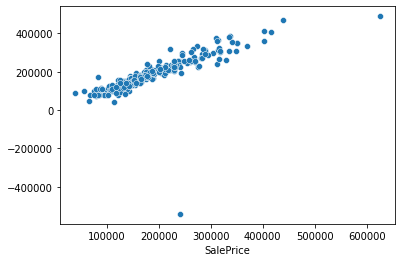

In [78]:


sns.scatterplot(x=y_test,y=y_predict)



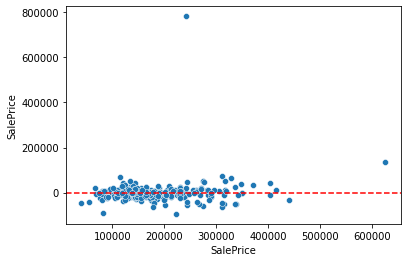

In [79]:


sns.scatterplot(x=y_test,y=RES_test)
plt.axhline(y=0,color='r',ls='--')



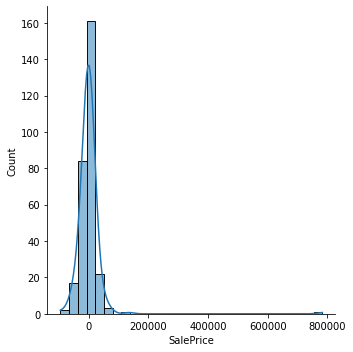

In [80]:


sns.displot(RES_test,bins=30, kde=True)

